## TP 4 — COVID-19 Detection in Chest X-Ray Images

### Objetivo
Desarrollar un sistema de **clasificación automática de imágenes médicas** capaz de detectar casos de **COVID-19** a partir de **radiografías de tórax (Chest X-Ray)**, utilizando técnicas de **procesamiento de imágenes** y **aprendizaje automático clásico**.

### Descripción del Dataset
Se dispone de un conjunto de datos compuesto por **más de 600 imágenes** de radiografías de tórax, organizadas en tres categorías:

- **COVID-19**
- **Normal**
- **Neumonía**

Las imágenes se encuentran estructuradas en carpetas, una por cada clase.

Repositorio del proyecto:  
https://github.com/manlio99/Materia-de-aprendizaje/blob/master/3_MidtermProjects/ProjectCXR

### Consigna
1. **Preprocesamiento de las imágenes**
   - Lectura de las imágenes.
   - Normalización y/o redimensionamiento si fuera necesario.
   - Conversión a escala de grises

2. **Extracción de características**
   - Diseñar e implementar un **extractor de características** adecuado para imágenes médicas.
   - Se pueden emplear descriptores clásicos como:
     - Histogramas de intensidad
     - HOG (Histogram of Oriented Gradients)
     - Textura (LBP, Haralick, etc.)
   - Justificar brevemente la elección del método.

3. **Entrenamiento del clasificador**
   - Utilizar las características extraídas para entrenar un **clasificador supervisado**.
   - Algunos modelos sugeridos:
     - K-Nearest Neighbors (KNN)
     - Support Vector Machines (SVM)
     - Random Forest
     - Naive Bayes

4. **Evaluación del modelo**
   - Evaluar el desempeño utilizando métricas apropiadas:
     - Accuracy
     - Precision
     - Recall
     - F1-score
   - Analizar los resultados obtenidos y discutir posibles mejoras.

In [1]:
import os
import numpy as np
import pandas as pd
import requests
import time
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from tqdm import tqdm
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
from glob import glob
from pathlib import Path

from skimage import io, color
from skimage.transform import resize
from skimage.exposure import rescale_intensity
from skimage.feature import hog
from skimage.feature import local_binary_pattern

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    balanced_accuracy_score,
    confusion_matrix
)

from utils import *

warnings.filterwarnings("ignore")

In [2]:
path_data = os.path.join(os.getcwd(), "data")
path = Path(path_data)
path.mkdir(parents=True, exist_ok=True)

In [ ]:
url = "https://data.mendeley.com/public-api/zip/fvk7h5dg2p/download/1"
output_path = os.path.join(path_data, "dataset.zip")

start_time = time.time()

response = requests.get(url, stream=True)
response.raise_for_status()

total_size = int(response.headers.get("content-length", 0))
chunk_size = 8192

with open(output_path, "wb") as f, tqdm(
    total=total_size,
    unit="B",
    unit_scale=True,
    desc="Downloading dataset"
) as pbar:
    for chunk in response.iter_content(chunk_size=chunk_size):
        if chunk:
            f.write(chunk)
            pbar.update(len(chunk))

elapsed = time.time() - start_time
print(f"\nDownload completed in {elapsed:.2f} seconds")

In [ ]:
import zipfile

with zipfile.ZipFile(path_data + "\\dataset.zip", "r") as zip_ref:
    
    zip_ref.extractall(path_data)

In [3]:
@dataclass(frozen=True)
class Cfg:
    data_dir: Path                 # carpeta raíz del dataset
    image_size: Tuple[int, int]    # (W, H)
    lbp_points: int
    lbp_radius: int
    hog_orientations: int
    hog_pixels_per_cell: Tuple[int, int]
    hog_cells_per_block: Tuple[int, int]
    hist_bins: int
    seed: int

CFG = Cfg(
    data_dir=Path(path_data),
    image_size=(224, 224),
    lbp_points=8,
    lbp_radius=1,
    hog_orientations=9,
    hog_pixels_per_cell=(16, 16),
    hog_cells_per_block=(2, 2),
    hist_bins=32,
    seed=42
)

In [4]:
# utils: carga por carpetas (labels = nombre de carpeta)
def list_image_files(root, exts=(".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
    
    files = []
    for ext in exts:
        files.extend(root.rglob(f"*{ext}"))
        files.extend(root.rglob(f"*{ext.upper()}"))
    return sorted(set(files))

def build_index_from_folders(data_dir):
    """
    Espera estructura:
        data_dir/
            COVID_19/
            Normal/
            Pneumonia/
    (o cualquier nombre de clase)
    """
    if not data_dir.exists():
        
        raise FileNotFoundError(f"No existe: {data_dir.resolve()}")

    class_dirs = [p for p in data_dir.iterdir() if p.is_dir()]
    
    if not class_dirs:
        
        raise ValueError(f"No hay subcarpetas de clases dentro de {data_dir}")

    # Orden estable
    class_names = sorted([p.name for p in class_dirs])

    paths: List[Path] = []
    labels: List[int] = []

    for i, cname in enumerate(class_names):
        cdir = data_dir / cname
        imgs = list_image_files(cdir)
        if len(imgs) == 0:
            print(f"[WARN] Carpeta sin imágenes: {cdir}")
            continue
        paths.extend(imgs)
        labels.extend([i] * len(imgs))

    if len(paths) == 0:
        raise ValueError("No se encontraron imágenes en las carpetas de clase.")

    idx_to_class = {i: name for i, name in enumerate(class_names)}
    y = np.array(labels, dtype=np.int32)

    return paths, y, idx_to_class

paths, y, idx_to_class = build_index_from_folders(CFG.data_dir)

print("Total imágenes:", len(paths))
print("Clases:", idx_to_class)
unique, counts = np.unique(y, return_counts=True)
print("Distribución:", {idx_to_class[int(k)]: int(v) for k, v in zip(unique, counts)})

Total imágenes: 603
Clases: {0: 'COVID_19', 1: 'Normal', 2: 'Pneumonia'}
Distribución: {'COVID_19': 221, 'Normal': 234, 'Pneumonia': 148}


In [5]:
# Construcción del dataset de features (X) + manejo de errores
def build_feature_matrix(paths, y, cfg):
    
    X_list = []
    y_list = []
    kept_paths = []

    for i, p in enumerate(paths):
        try:
            feat = extract_features_from_path(p, cfg)
            X_list.append(feat)
            y_list.append(int(y[i]))
            kept_paths.append(p)
        except Exception as e:
            print(f"[WARN] Saltando {p.name}: {e}")

    X = np.vstack(X_list).astype(np.float32)
    y2 = np.array(y_list, dtype=np.int32)
    return X, y2, kept_paths

X, y2, kept_paths = build_feature_matrix(paths, y, CFG)

print("X shape:", X.shape)
print("y shape:", y2.shape)

X shape: (603, 6133)
y shape: (603,)


In [6]:
# Split estratificado: train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y2,
    test_size=0.2,
    random_state=CFG.seed,
    stratify=y2
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (482, 6133) Test: (121, 6133)


In [7]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [8]:
def plot_cm(cm, class_names, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, f"{cm[i, j]}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )
    plt.tight_layout()
    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.show()

In [9]:
# 3 modelos: SVM, RF, MLP
models = {
    "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC())
        ]),
        [
            {"clf__kernel": ["linear"], "clf__C": [0.1, 0.5, 1, 2, 5]},
            {"clf__kernel": ["rbf"], "clf__C": [0.5, 1, 2, 5, 10], "clf__gamma": ["scale", 0.01, 0.05, 0.1]},
        ]
    ),

    "RF": (
        Pipeline([
            ("clf", RandomForestClassifier(random_state=CFG.seed, n_jobs=-1))
        ]),
        {
            "clf__n_estimators": [300, 600],
            "clf__max_depth": [None, 12, 20],
            "clf__min_samples_split": [2, 5],
            "clf__min_samples_leaf": [1, 2],
            "clf__class_weight": [None, "balanced"]
        }
    ),

    "MLP": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                random_state=CFG.seed,
                max_iter=200,
                early_stopping=True,
                n_iter_no_change=12,
                validation_fraction=0.15
            ))
        ]),
        {
            "clf__hidden_layer_sizes": [(256,), (256, 128), (512, 256)],
            "clf__alpha": [1e-4, 1e-3, 1e-2],
            "clf__learning_rate_init": [1e-3, 5e-4],
            "clf__activation": ["relu", "tanh"]
        }
    )
}



============================ SVM ============================
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Best params: {'clf__C': 0.1, 'clf__kernel': 'linear'}
Best CV f1_macro: 0.9298652343121315
TEST  Acc=0.9008 | BalAcc=0.8823 | F1_macro=0.8900

Report:
               precision    recall  f1-score   support

    COVID_19       0.96      0.98      0.97        44
      Normal       0.85      0.94      0.89        47
   Pneumonia       0.92      0.73      0.81        30

    accuracy                           0.90       121
   macro avg       0.91      0.88      0.89       121
weighted avg       0.90      0.90      0.90       121



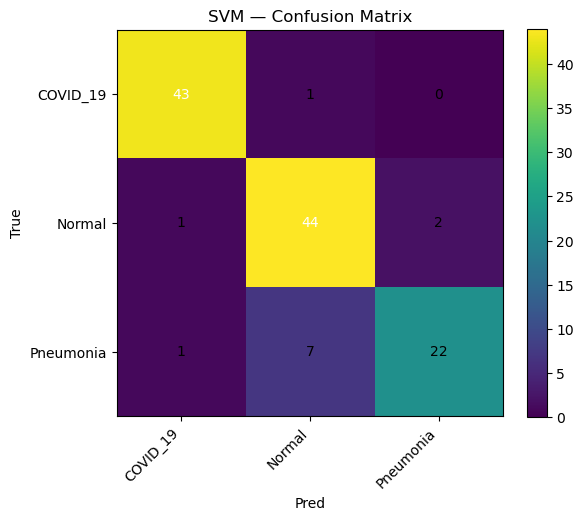


============================ RF ============================
Fitting 10 folds for each of 48 candidates, totalling 480 fits
Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best CV f1_macro: 0.9144414022417454
TEST  Acc=0.9174 | BalAcc=0.9085 | F1_macro=0.9095

Report:
               precision    recall  f1-score   support

    COVID_19       0.96      0.98      0.97        44
      Normal       0.91      0.91      0.91        47
   Pneumonia       0.86      0.83      0.85        30

    accuracy                           0.92       121
   macro avg       0.91      0.91      0.91       121
weighted avg       0.92      0.92      0.92       121



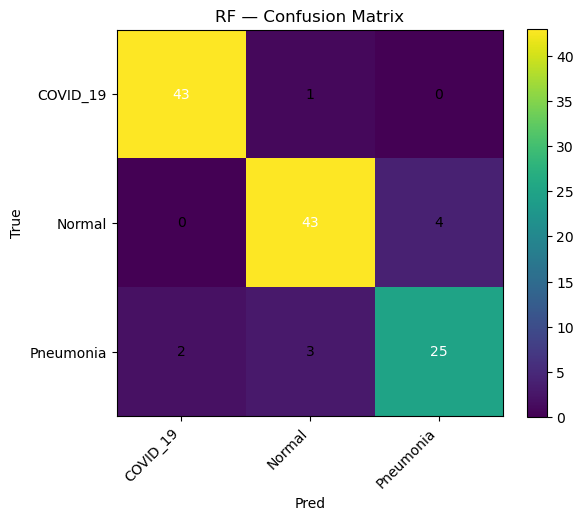


============================ MLP ============================
Fitting 10 folds for each of 36 candidates, totalling 360 fits
Best params: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (256, 128), 'clf__learning_rate_init': 0.0005}
Best CV f1_macro: 0.9087118372381531
TEST  Acc=0.9421 | BalAcc=0.9378 | F1_macro=0.9396

Report:
               precision    recall  f1-score   support

    COVID_19       0.98      0.98      0.98        44
      Normal       0.92      0.94      0.93        47
   Pneumonia       0.93      0.90      0.92        30

    accuracy                           0.94       121
   macro avg       0.94      0.94      0.94       121
weighted avg       0.94      0.94      0.94       121



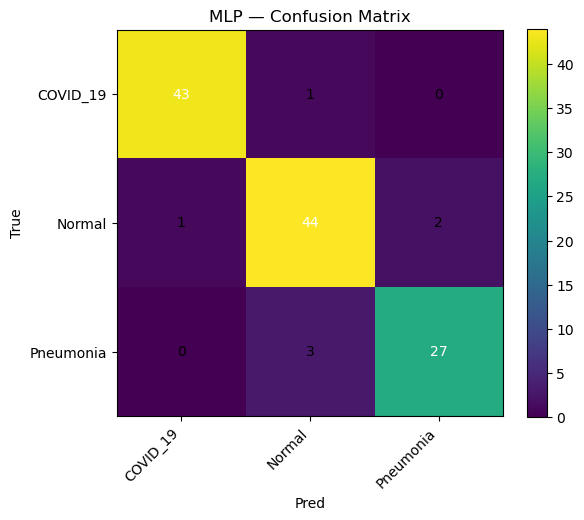

[('SVM',
  np.float64(0.9298652343121315),
  0.9008264462809917,
  0.8822587577906726,
  0.8899986128450549,
  {'clf__C': 0.1, 'clf__kernel': 'linear'}),
 ('RF',
  np.float64(0.9144414022417454),
  0.9173553719008265,
  0.9084998925424458,
  0.9095477929904604,
  {'clf__class_weight': 'balanced',
   'clf__max_depth': None,
   'clf__min_samples_leaf': 2,
   'clf__min_samples_split': 2,
   'clf__n_estimators': 300}),
 ('MLP',
  np.float64(0.9087118372381531),
  0.9421487603305785,
  0.9378143133462283,
  0.939614251344849,
  {'clf__activation': 'relu',
   'clf__alpha': 0.0001,
   'clf__hidden_layer_sizes': (256, 128),
   'clf__learning_rate_init': 0.0005})]

In [10]:
results = []

class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

models_to_save = []

for name, (pipe, grid_params) in models.items():
    print("\n" + "="*28, name, "="*28)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=grid_params,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2
    )
    grid.fit(X_train, y_train)

    best = grid.best_estimator_
    print("Best params:", grid.best_params_)
    print("Best CV f1_macro:", grid.best_score_)

    y_pred = best.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")

    print(f"TEST  Acc={acc:.4f} | BalAcc={bacc:.4f} | F1_macro={f1m:.4f}")
    print("\nReport:\n", classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    plot_cm(cm, class_names, title=f"{name} — Confusion Matrix")

    results.append((name, grid.best_score_, acc, bacc, f1m, grid.best_params_))

    models_to_save.append({
        "name": name,
        "model": best,
        "best_params": grid.best_params_,
        "best_cv_f1_macro": grid.best_score_,
        "test_metrics": {
            "acc": acc, 
            "bal_acc": bacc, 
            "f1_macro": f1m
        },
        "cfg": CFG,
        "idx_to_class": idx_to_class,
    })

display(results)

In [11]:
# Ranking final
results_sorted = sorted(results, key=lambda x: x[4], reverse=True)  # por F1_macro test
print("\n Ranking por F1_macro (TEST)")
for (name, cv_f1, acc, bacc, f1m, params) in results_sorted:
    print(f"{name:>4} | CV f1_macro={cv_f1:.4f} | TEST F1_macro={f1m:.4f} | Acc={acc:.4f} | BalAcc={bacc:.4f}")
    print("      params:", params)


 Ranking por F1_macro (TEST)
 MLP | CV f1_macro=0.9087 | TEST F1_macro=0.9396 | Acc=0.9421 | BalAcc=0.9378
      params: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (256, 128), 'clf__learning_rate_init': 0.0005}
  RF | CV f1_macro=0.9144 | TEST F1_macro=0.9095 | Acc=0.9174 | BalAcc=0.9085
      params: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
 SVM | CV f1_macro=0.9299 | TEST F1_macro=0.8900 | Acc=0.9008 | BalAcc=0.8823
      params: {'clf__C': 0.1, 'clf__kernel': 'linear'}


In [13]:
# Guardar el modelo
import joblib

out_dir = Path(os.path.join(os.getcwd(), "data_models"))
out_dir.mkdir(exist_ok=True)

for bundle in models_to_save:
    model_name = bundle["name"]   # "SVM", "MLP", "RF"
    fname = out_dir / f"cxr_{model_name.lower()}_best.joblib"

    joblib.dump(bundle, fname)
    print(f"Saved {model_name} → {fname}")

Saved SVM → C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\doctorado_ingenieria_uns\ml2025\repo\uns_diec_ml\tp_4\data_models\cxr_svm_best.joblib
Saved RF → C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\doctorado_ingenieria_uns\ml2025\repo\uns_diec_ml\tp_4\data_models\cxr_rf_best.joblib
Saved MLP → C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\doctorado_ingenieria_uns\ml2025\repo\uns_diec_ml\tp_4\data_models\cxr_mlp_best.joblib


# Try Models

In [43]:
bundle = joblib.load("data_models/cxr_svm_best.joblib")  # o svm / rf

model = bundle["model"]
CFG = bundle["cfg"]
idx_to_class = bundle["idx_to_class"]

print("Modelo cargado:", type(model))
print("Clases:", idx_to_class)

Modelo cargado: <class 'sklearn.pipeline.Pipeline'>
Clases: {0: 'COVID_19', 1: 'Normal', 2: 'Pneumonia'}


In [44]:
img_path = Path("life/nor.jpg")

x = extract_features_from_path(img_path, CFG)
X = x.reshape(1, -1)  # (1, n_features)

y_pred = model.predict(X)[0]
pred_class = idx_to_class[int(y_pred)]

print("Predicción:", pred_class)

Predicción: Normal


In [45]:
bundle = joblib.load("data_models/cxr_mlp_best.joblib") 

model = bundle["model"]
CFG = bundle["cfg"]
idx_to_class = bundle["idx_to_class"]

print("Modelo cargado:", type(model))
print("Clases:", idx_to_class)

Modelo cargado: <class 'sklearn.pipeline.Pipeline'>
Clases: {0: 'COVID_19', 1: 'Normal', 2: 'Pneumonia'}


In [46]:
img_path = Path("life/nor.jpg")

x = extract_features_from_path(img_path, CFG)
X = x.reshape(1, -1)  # (1, n_features)

y_pred = model.predict(X)[0]
pred_class = idx_to_class[int(y_pred)]

print("Predicción:", pred_class)

Predicción: Normal


In [47]:
bundle = joblib.load("data_models/cxr_rf_best.joblib") 

model = bundle["model"]
CFG = bundle["cfg"]
idx_to_class = bundle["idx_to_class"]

print("Modelo cargado:", type(model))
print("Clases:", idx_to_class)

Modelo cargado: <class 'sklearn.pipeline.Pipeline'>
Clases: {0: 'COVID_19', 1: 'Normal', 2: 'Pneumonia'}


In [48]:
img_path = Path("life/nor.jpg")

x = extract_features_from_path(img_path, CFG)
X = x.reshape(1, -1)  # (1, n_features)

y_pred = model.predict(X)[0]
pred_class = idx_to_class[int(y_pred)]

print("Predicción:", pred_class)

Predicción: Normal


## Conclusiones

### Desempeño de los modelos
Se evaluaron tres modelos clásicos de Aprendizaje Automático (MLP, Random Forest y SVM) para la clasificación de radiografías de tórax en tres clases: **COVID-19, Normal y Neumonía**.  
La métrica principal utilizada fue **F1-macro**, adecuada para problemas multiclase y posibles desbalances.

**Ranking por F1-macro en el conjunto de test:**

1. **MLP (Perceptrón Multicapa)**
   - F1-macro (test): **0.9396**
   - Accuracy: 0.9421
   - Balanced Accuracy: 0.9378

2. **Random Forest**
   - F1-macro (test): **0.9095**
   - Accuracy: 0.9174
   - Balanced Accuracy: 0.9085

3. **SVM (kernel lineal)**
   - F1-macro (test): **0.8900**
   - Accuracy: 0.9008
   - Balanced Accuracy: 0.8823

---

### Análisis de resultados

- El **MLP** obtuvo el mejor desempeño global, mostrando una excelente capacidad de generalización incluso sin aplicar técnicas de *data augmentation*. Esto indica que el modelo logra capturar relaciones no lineales complejas entre las características extraídas.
  
- El **Random Forest** presentó un comportamiento robusto y estable, con una leve caída respecto al MLP. Su desempeño consistente sugiere buena tolerancia al ruido y menor sensibilidad al escalado de variables.

- El **SVM lineal**, si bien alcanzó el mejor resultado en validación cruzada, fue el que peor generalizó en el conjunto de test. Esto sugiere un **subajuste (underfitting)** y una alta sensibilidad a variaciones en el dominio de los datos, especialmente frente a imágenes externas al dataset original.

---

### Conclusión general
Sin aplicar técnicas de *data augmentation*, los resultados muestran que:

- El **MLP es el modelo más adecuado** para este conjunto de características.
- El **Random Forest** es una alternativa sólida y estable.
- El **SVM lineal** requiere mejoras adicionales (por ejemplo, PCA, kernel RBF o augmentations) para lograr una mejor generalización.

---

## Feature Engineering

### Preprocesamiento de imágenes
Antes de la extracción de características, las imágenes fueron sometidas a un preprocesamiento uniforme que incluyó:

- Conversión a escala de grises.
- Redimensionamiento a un tamaño fijo.
- Aplicación de **CLAHE (Contrast Limited Adaptive Histogram Equalization)** para mejorar el contraste local.
- Suavizado leve para reducción de ruido.

Este preprocesamiento busca reducir variaciones de adquisición y resaltar estructuras pulmonares relevantes.

---

### Características extraídas

#### HOG (Histogram of Oriented Gradients)
- Captura información de **bordes y gradientes**.
- Es sensible a cambios estructurales en los pulmones, como opacidades y patrones irregulares.
- Proporciona una representación detallada de la forma y estructura anatómica.

#### LBP (Local Binary Patterns)
- Describe **texturas locales**.
- Permite diferenciar tejidos homogéneos de patrones texturales complejos.
- Resulta especialmente útil para distinguir pulmones sanos de aquellos con infecciones.

#### Histograma de intensidades y estadísticas globales
Incluye:
- Histograma de intensidades normalizado.
- Estadísticas como media, desviación estándar y percentiles.

Estas características reflejan cambios globales.ntensidades, asociados a consolidaciones pulmonares y pérdida de aireación.

---

### Justificación del enfoque híbrido
Cada tipo de característica aporta información complementaria:

| Descriptor | Información capturada |
|-----------|-----------------------|
| HOG | Estructura y forma |
| LBP | Textura local |
| Histograma + estadísticas | Intensidad global |

La combinación de estos descriptores genera un **espacio de características rico y discriminativo**, adecuado para modelos clásicos de ML y especialmente efectivo para modelos no lineales como el MLP.

---

### Conclusión final
El estudio demuestra que un **pipeline de Machine Learning clásico**, acompañado de un diseño cuidadoso de *feature engineering*, puede alcanzar un alto desempeño en la clasificación de radiografías de tórax.  
La incorporación futura de *data augmentation* y/o mejoras en el modelo SVM podría incrementar aún más la capacidad de generalización del sistema.
